In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import sklearn
from google.colab import files

SEED = 42
np.random.seed(SEED)

OUTPUT_DIR = Path("/content/random_forest_results")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("scikit-learn version:", sklearn.__version__)

# Upload both files together.
files.upload()

print("\nAvailable CSV files:")
for path in Path("/content").glob("*.csv"):
    print(path.name)

scikit-learn version: 1.6.1


Saving online_shoppers_intention.csv to online_shoppers_intention.csv
Saving y_test (1).csv to y_test (1).csv

Available CSV files:
y_test (1).csv
online_shoppers_intention.csv


In [2]:
from sklearn.model_selection import train_test_split

df = pd.read_csv("/content/online_shoppers_intention.csv")
supplied_y_test = pd.read_csv(
    "/content/y_test (1).csv"
)["Revenue"].to_numpy()

print("Original shape:", df.shape)
print("Missing values:", df.isna().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

df = df.drop_duplicates().reset_index(drop=True)

X = df.drop(columns="Revenue")
y = df["Revenue"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=SEED
)

assert np.array_equal(y_test.to_numpy(), supplied_y_test), (
    "Test labels do not match the supplied file."
)

print("\nTraining shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nTraining class counts:")
print(y_train.value_counts().sort_index())
print("\nTest label order verified.")

# Record row indices so the split can be reproduced.
pd.DataFrame({
    "row_index_after_deduplication": X_train.index
}).to_csv(OUTPUT_DIR / "train_indices.csv", index=False)

pd.DataFrame({
    "row_index_after_deduplication": X_test.index
}).to_csv(OUTPUT_DIR / "test_indices.csv", index=False)

Original shape: (12330, 18)
Missing values: 0
Duplicate rows: 125

Training shape: (9764, 17)
Test shape: (2441, 17)

Training class counts:
Revenue
0    8238
1    1526
Name: count, dtype: int64

Test label order verified.


In [3]:
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate

categorical_cols = [
    "Month", "OperatingSystems", "Browser",
    "Region", "TrafficType", "VisitorType", "Weekend"
]

numerical_cols = [
    col for col in X_train.columns
    if col not in categorical_cols
]

numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer([
    ("numerical", numerical_pipeline, numerical_cols),
    ("categorical", categorical_pipeline, categorical_cols)
])

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

scoring = {
    "f1": "f1",
    "precision": "precision",
    "recall": "recall",
    "roc_auc": "roc_auc",
    "average_precision": "average_precision"
}

print("Numerical features:", len(numerical_cols))
print("Categorical features:", len(categorical_cols))
print("CV: 5 stratified folds")
print("Selection metric: purchase-class F1")
print("Preprocessing defined; not fitted.")

Numerical features: 10
Categorical features: 7
CV: 5 stratified folds
Selection metric: purchase-class F1
Preprocessing defined; not fitted.


In [4]:
import json

# Preserve completed results if this cell is rerun.
if "cv_results" not in globals():
    cv_results = {}

if "candidate_models" not in globals():
    candidate_models = {}

def evaluate_variety(name, candidate):
    print(f"Evaluating: {name}", flush=True)

    scores = cross_validate(
        candidate,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=True,
        n_jobs=1,
        error_score="raise"
    )

    row = {
        "Variety": name,
        "Parameters": json.dumps(
            candidate.named_steps["model"].get_params(),
            default=str
        ),
        "Train F1": scores["train_f1"].mean(),
        "CV F1 std": scores["test_f1"].std(ddof=1)
    }

    for metric in scoring:
        row[f"CV {metric}"] = scores[f"test_{metric}"].mean()

    cv_results[name] = row
    candidate_models[name] = clone(candidate)

    # Save individual fold scores and the comparison table.
    pd.DataFrame(scores).to_csv(
        OUTPUT_DIR / f"{name.lower().replace(' ', '_')}_fold_scores.csv",
        index=False
    )

    table = pd.DataFrame(cv_results.values()).sort_values(
        "CV f1", ascending=False
    )
    table.to_csv(OUTPUT_DIR / "cv_comparison.csv", index=False)

    display(table.drop(columns="Parameters").round(4))
    return scores

baseline = Pipeline([
    ("preprocessing", clone(preprocessor)),
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=SEED,
        n_jobs=-1
    ))
])

baseline_scores = evaluate_variety("Baseline", baseline)

Evaluating: Baseline


,Variety,Train F1,CV F1 std,CV f1,CV precision,CV recall,CV roc_auc,CV average_precision
0,Baseline,1.0,0.0129,0.6137,0.7727,0.5092,0.9227,0.7369


In [5]:
varieties = {
    "Balanced weights": {
        "class_weight": "balanced"
    },
    "Balanced subsample": {
        "class_weight": "balanced_subsample"
    },
    "Regularized trees": {
        "max_depth": 12,
        "min_samples_leaf": 5
    },
    "Regularized balanced": {
        "max_depth": 12,
        "min_samples_leaf": 5,
        "class_weight": "balanced"
    }
}

for name, params in varieties.items():
    # Skip completed varieties when rerunning this cell.
    if name in cv_results:
        print(f"Already completed: {name}")
        continue

    candidate = Pipeline([
        ("preprocessing", clone(preprocessor)),
        ("model", RandomForestClassifier(
            n_estimators=100,
            random_state=SEED,
            n_jobs=-1,
            **params
        ))
    ])

    evaluate_variety(name, candidate)

comparison = pd.DataFrame(cv_results.values()).sort_values(
    "CV f1", ascending=False
)

print("\nCompleted comparison:")
print(
    comparison.drop(columns="Parameters")
    .round(4)
    .to_string(index=False)
)

Evaluating: Balanced weights


,Variety,Train F1,CV F1 std,CV f1,CV precision,CV recall,CV roc_auc,CV average_precision
0,Baseline,1.0,0.0129,0.6137,0.7727,0.5092,0.9227,0.7369
1,Balanced weights,1.0,0.0180,0.6066,0.7656,0.5026,0.9230,0.7311


Evaluating: Balanced subsample


,Variety,Train F1,CV F1 std,CV f1,CV precision,CV recall,CV roc_auc,CV average_precision
0,Baseline,1.0,0.0129,0.6137,0.7727,0.5092,0.9227,0.7369
1,Balanced weights,1.0,0.0180,0.6066,0.7656,0.5026,0.9230,0.7311
2,Balanced subsample,1.0,0.0194,0.6028,0.7701,0.4954,0.9243,0.7308


Evaluating: Regularized trees


,Variety,Train F1,CV F1 std,CV f1,CV precision,CV recall,CV roc_auc,CV average_precision
0,Baseline,1.0000,0.0129,0.6137,0.7727,0.5092,0.9227,0.7369
1,Balanced weights,1.0000,0.0180,0.6066,0.7656,0.5026,0.9230,0.7311
2,Balanced subsample,1.0000,0.0194,0.6028,0.7701,0.4954,0.9243,0.7308
3,Regularized trees,0.7236,0.0191,0.5945,0.8286,0.4640,0.9254,0.7494


Evaluating: Regularized balanced


,Variety,Train F1,CV F1 std,CV f1,CV precision,CV recall,CV roc_auc,CV average_precision
4,Regularized balanced,0.7335,0.0100,0.6668,0.5720,0.8001,0.9235,0.7187
0,Baseline,1.0000,0.0129,0.6137,0.7727,0.5092,0.9227,0.7369
1,Balanced weights,1.0000,0.0180,0.6066,0.7656,0.5026,0.9230,0.7311
2,Balanced subsample,1.0000,0.0194,0.6028,0.7701,0.4954,0.9243,0.7308
3,Regularized trees,0.7236,0.0191,0.5945,0.8286,0.4640,0.9254,0.7494



Completed comparison:
             Variety  Train F1  CV F1 std  CV f1  CV precision  CV recall  CV roc_auc  CV average_precision
Regularized balanced    0.7335     0.0100 0.6668        0.5720     0.8001      0.9235                0.7187
            Baseline    1.0000     0.0129 0.6137        0.7727     0.5092      0.9227                0.7369
    Balanced weights    1.0000     0.0180 0.6066        0.7656     0.5026      0.9230                0.7311
  Balanced subsample    1.0000     0.0194 0.6028        0.7701     0.4954      0.9243                0.7308
   Regularized trees    0.7236     0.0191 0.5945        0.8286     0.4640      0.9254                0.7494


In [6]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler

rf_settings = {
    "n_estimators": 100,
    "max_depth": 12,
    "min_samples_leaf": 5,
    "random_state": SEED,
    "n_jobs": -1
}

undersampled = ImbPipeline([
    ("preprocessing", clone(preprocessor)),
    ("sampling", RandomUnderSampler(random_state=SEED)),
    ("model", RandomForestClassifier(**rf_settings))
])

preprocessor_no_pagevalues = ColumnTransformer([
    ("numerical", clone(numerical_pipeline), [
        col for col in numerical_cols if col != "PageValues"
    ]),
    ("categorical", clone(categorical_pipeline), categorical_cols)
])

without_pagevalues = Pipeline([
    ("preprocessing", preprocessor_no_pagevalues),
    ("model", RandomForestClassifier(
        **rf_settings,
        class_weight="balanced"
    ))
])

additional_varieties = {
    "Regularized undersampling": undersampled,
    "Regularized balanced without PageValues": without_pagevalues
}

for name, candidate in additional_varieties.items():
    if name in cv_results:
        print(f"Already completed: {name}")
        continue

    evaluate_variety(name, candidate)

comparison = pd.DataFrame(cv_results.values()).sort_values(
    "CV f1", ascending=False
)

print("\nCompleted comparison:")
print(
    comparison.drop(columns="Parameters")
    .round(4)
    .to_string(index=False)
)

Evaluating: Regularized undersampling


,Variety,Train F1,CV F1 std,CV f1,CV precision,CV recall,CV roc_auc,CV average_precision
4,Regularized balanced,0.7335,0.0100,0.6668,0.5720,0.8001,0.9235,0.7187
5,Regularized undersampling,0.6730,0.0109,0.6435,0.5183,0.8499,0.9207,0.7015
0,Baseline,1.0000,0.0129,0.6137,0.7727,0.5092,0.9227,0.7369
1,Balanced weights,1.0000,0.0180,0.6066,0.7656,0.5026,0.9230,0.7311
2,Balanced subsample,1.0000,0.0194,0.6028,0.7701,0.4954,0.9243,0.7308
3,Regularized trees,0.7236,0.0191,0.5945,0.8286,0.4640,0.9254,0.7494


Evaluating: Regularized balanced without PageValues


,Variety,Train F1,CV F1 std,CV f1,CV precision,CV recall,CV roc_auc,CV average_precision
4,Regularized balanced,0.7335,0.0100,0.6668,0.5720,0.8001,0.9235,0.7187
5,Regularized undersampling,0.6730,0.0109,0.6435,0.5183,0.8499,0.9207,0.7015
0,Baseline,1.0000,0.0129,0.6137,0.7727,0.5092,0.9227,0.7369
1,Balanced weights,1.0000,0.0180,0.6066,0.7656,0.5026,0.9230,0.7311
2,Balanced subsample,1.0000,0.0194,0.6028,0.7701,0.4954,0.9243,0.7308
3,Regularized trees,0.7236,0.0191,0.5945,0.8286,0.4640,0.9254,0.7494
6,Regularized balanced without PageValues,0.5792,0.0227,0.4239,0.3204,0.6265,0.7737,0.3823



Completed comparison:
                                Variety  Train F1  CV F1 std  CV f1  CV precision  CV recall  CV roc_auc  CV average_precision
                   Regularized balanced    0.7335     0.0100 0.6668        0.5720     0.8001      0.9235                0.7187
              Regularized undersampling    0.6730     0.0109 0.6435        0.5183     0.8499      0.9207                0.7015
                               Baseline    1.0000     0.0129 0.6137        0.7727     0.5092      0.9227                0.7369
                       Balanced weights    1.0000     0.0180 0.6066        0.7656     0.5026      0.9230                0.7311
                     Balanced subsample    1.0000     0.0194 0.6028        0.7701     0.4954      0.9243                0.7308
                      Regularized trees    0.7236     0.0191 0.5945        0.8286     0.4640      0.9254                0.7494
Regularized balanced without PageValues    0.5792     0.0227 0.4239        0.3204     0.

In [7]:
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from imblearn.over_sampling import SMOTENC

before_sampling = ColumnTransformer([
    ("numerical", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), numerical_cols),

    ("categorical", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OrdinalEncoder(
            handle_unknown="use_encoded_value",
            unknown_value=-1
        ))
    ]), categorical_cols)
])

num_indices = list(range(len(numerical_cols)))
cat_indices = list(range(
    len(numerical_cols),
    len(numerical_cols) + len(categorical_cols)
))

after_sampling = ColumnTransformer([
    ("numerical", "passthrough", num_indices),
    ("categorical", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ), cat_indices)
])

smotenc_candidate = ImbPipeline([
    ("preprocessing", before_sampling),
    ("sampling", SMOTENC(
        categorical_features=cat_indices,
        random_state=SEED,
        k_neighbors=5
    )),
    ("encoding", after_sampling),
    ("model", RandomForestClassifier(**rf_settings))
])

name = "Regularized SMOTENC"

if name not in cv_results:
    evaluate_variety(name, smotenc_candidate)
else:
    print(f"Already completed: {name}")

comparison = pd.DataFrame(cv_results.values()).sort_values(
    "CV f1", ascending=False
)

print(comparison.drop(columns="Parameters").round(4).to_string(index=False))

# Download a checkpoint of all results saved so far.
import shutil

checkpoint = shutil.make_archive(
    "/content/random_forest_checkpoint",
    "zip",
    root_dir=str(OUTPUT_DIR)
)
files.download(checkpoint)

Evaluating: Regularized SMOTENC


,Variety,Train F1,CV F1 std,CV f1,CV precision,CV recall,CV roc_auc,CV average_precision
4,Regularized balanced,0.7335,0.0100,0.6668,0.5720,0.8001,0.9235,0.7187
7,Regularized SMOTENC,0.7355,0.0095,0.6657,0.5802,0.7811,0.9159,0.6620
5,Regularized undersampling,0.6730,0.0109,0.6435,0.5183,0.8499,0.9207,0.7015
0,Baseline,1.0000,0.0129,0.6137,0.7727,0.5092,0.9227,0.7369
1,Balanced weights,1.0000,0.0180,0.6066,0.7656,0.5026,0.9230,0.7311
2,Balanced subsample,1.0000,0.0194,0.6028,0.7701,0.4954,0.9243,0.7308
3,Regularized trees,0.7236,0.0191,0.5945,0.8286,0.4640,0.9254,0.7494
6,Regularized balanced without PageValues,0.5792,0.0227,0.4239,0.3204,0.6265,0.7737,0.3823


                                Variety  Train F1  CV F1 std  CV f1  CV precision  CV recall  CV roc_auc  CV average_precision
                   Regularized balanced    0.7335     0.0100 0.6668        0.5720     0.8001      0.9235                0.7187
                    Regularized SMOTENC    0.7355     0.0095 0.6657        0.5802     0.7811      0.9159                0.6620
              Regularized undersampling    0.6730     0.0109 0.6435        0.5183     0.8499      0.9207                0.7015
                               Baseline    1.0000     0.0129 0.6137        0.7727     0.5092      0.9227                0.7369
                       Balanced weights    1.0000     0.0180 0.6066        0.7656     0.5026      0.9230                0.7311
                     Balanced subsample    1.0000     0.0194 0.6028        0.7701     0.4954      0.9243                0.7308
                      Regularized trees    0.7236     0.0191 0.5945        0.8286     0.4640      0.9254       

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [8]:
import joblib

# Selected earlier using RandomizedSearchCV, then GridSearchCV.
# These settings remain fixed after the earlier test evaluation.
selected_params = {
    "n_estimators": 100,
    "max_depth": 12,
    "min_samples_leaf": 5,
    "max_features": 0.5,
    "criterion": "gini",
    "class_weight": "balanced",
    "random_state": SEED,
    "n_jobs": -1
}

final_model = Pipeline([
    ("preprocessing", clone(preprocessor)),
    ("model", RandomForestClassifier(**selected_params))
])

name = "Previously tuned balanced"

if name not in cv_results:
    evaluate_variety(name, final_model)

# Fit the fixed configuration on all training data.
final_model.fit(X_train, y_train)

model_path = OUTPUT_DIR / "random_forest_pipeline.joblib"
joblib.dump(final_model, model_path)

metadata = {
    "selected_parameters": selected_params,
    "selection_metric": "purchase-class F1",
    "selection_history": (
        "Earlier run: 24-candidate RandomizedSearchCV, followed "
        "by 9-candidate GridSearchCV; both used 5 stratified folds."
    ),
    "earlier_best_cv_f1": 0.683720,
    "test_previously_evaluated": True,
    "input_columns": list(X_train.columns),
    "sklearn_version": sklearn.__version__
}

(OUTPUT_DIR / "model_metadata.json").write_text(
    json.dumps(metadata, indent=2)
)

print("\nFinal pipeline fitted and saved.")
files.download(str(model_path))

Evaluating: Previously tuned balanced


,Variety,Train F1,CV F1 std,CV f1,CV precision,CV recall,CV roc_auc,CV average_precision
8,Previously tuned balanced,0.8168,0.0170,0.6837,0.6175,0.7667,0.9316,0.7494
4,Regularized balanced,0.7335,0.0100,0.6668,0.5720,0.8001,0.9235,0.7187
7,Regularized SMOTENC,0.7355,0.0095,0.6657,0.5802,0.7811,0.9159,0.6620
5,Regularized undersampling,0.6730,0.0109,0.6435,0.5183,0.8499,0.9207,0.7015
0,Baseline,1.0000,0.0129,0.6137,0.7727,0.5092,0.9227,0.7369
1,Balanced weights,1.0000,0.0180,0.6066,0.7656,0.5026,0.9230,0.7311
2,Balanced subsample,1.0000,0.0194,0.6028,0.7701,0.4954,0.9243,0.7308
3,Regularized trees,0.7236,0.0191,0.5945,0.8286,0.4640,0.9254,0.7494
6,Regularized balanced without PageValues,0.5792,0.0227,0.4239,0.3204,0.6265,0.7737,0.3823



Final pipeline fitted and saved.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

           Metric  Test score
        Precision      0.6068
           Recall      0.7513
               F1      0.6713
          ROC-AUC      0.9320
Average precision      0.7398
         Accuracy      0.8849

TN=1873, FP=186, FN=95, TP=287


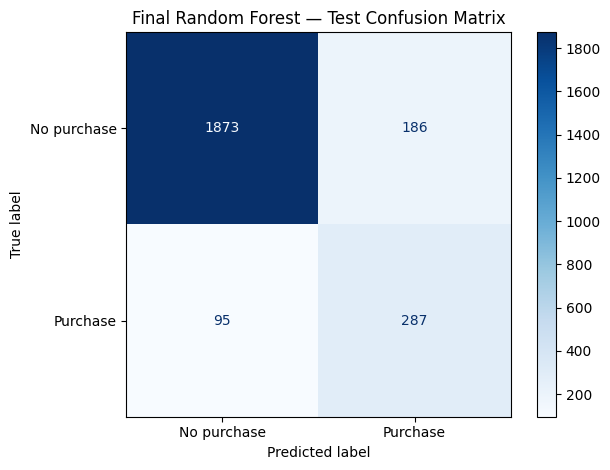

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, accuracy_score,
    confusion_matrix, ConfusionMatrixDisplay
)

y_pred = final_model.predict(X_test)
positive_index = list(
    final_model.named_steps["model"].classes_
).index(1)

y_probability = final_model.predict_proba(X_test)[:, positive_index]

test_metrics = {
    "Precision": precision_score(y_test, y_pred, zero_division=0),
    "Recall": recall_score(y_test, y_pred, zero_division=0),
    "F1": f1_score(y_test, y_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_probability),
    "Average precision": average_precision_score(
        y_test, y_probability
    ),
    "Accuracy": accuracy_score(y_test, y_pred)
}

metrics_table = pd.DataFrame(
    test_metrics.items(), columns=["Metric", "Test score"]
)
metrics_table.to_csv(OUTPUT_DIR / "test_metrics.csv", index=False)
print(metrics_table.round(4).to_string(index=False))

cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

print(f"\nTN={tn}, FP={fp}, FN={fn}, TP={tp}")

pd.DataFrame(
    cm,
    index=["Actual no purchase", "Actual purchase"],
    columns=["Predicted no purchase", "Predicted purchase"]
).to_csv(OUTPUT_DIR / "confusion_matrix.csv")

pd.DataFrame({
    "row_index_after_deduplication": X_test.index,
    "actual": y_test.to_numpy(),
    "predicted": y_pred,
    "purchase_probability": y_probability
}).to_csv(OUTPUT_DIR / "test_predictions.csv", index=False)

ConfusionMatrixDisplay(
    cm, display_labels=["No purchase", "Purchase"]
).plot(cmap="Blues", values_format="d")

plt.title("Final Random Forest — Test Confusion Matrix")
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "confusion_matrix.png",
    dpi=200, bbox_inches="tight"
)
plt.show()

# Download the updated backup, including the fitted model.
archive = shutil.make_archive(
    "/content/random_forest_results",
    "zip",
    root_dir=str(OUTPUT_DIR)
)
files.download(archive)

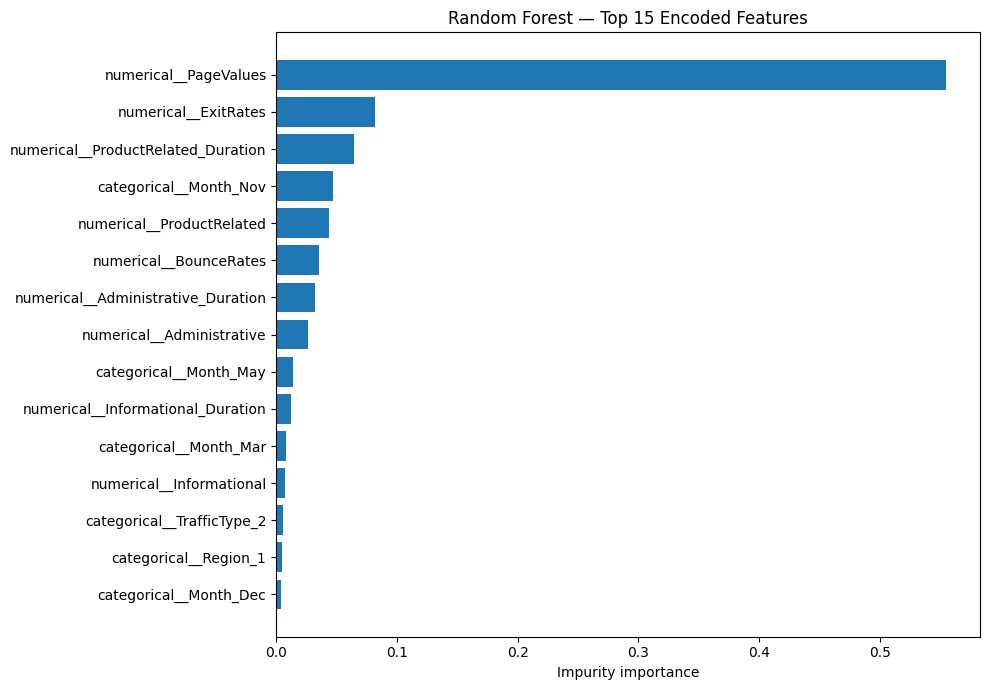

Calculating permutation importance...
                Feature  Mean F1 decrease    Std
             PageValues            0.4644 0.0121
                  Month            0.0068 0.0045
              ExitRates            0.0052 0.0073
            TrafficType            0.0003 0.0015
         ProductRelated            0.0002 0.0051
       OperatingSystems           -0.0001 0.0023
            VisitorType           -0.0002 0.0008
 Informational_Duration           -0.0004 0.0025
             SpecialDay           -0.0006 0.0014
         Administrative           -0.0010 0.0026
                Weekend           -0.0015 0.0013
          Informational           -0.0031 0.0027
                Browser           -0.0034 0.0006
            BounceRates           -0.0043 0.0035
Administrative_Duration           -0.0054 0.0014
                 Region           -0.0100 0.0030
ProductRelated_Duration           -0.0173 0.0024


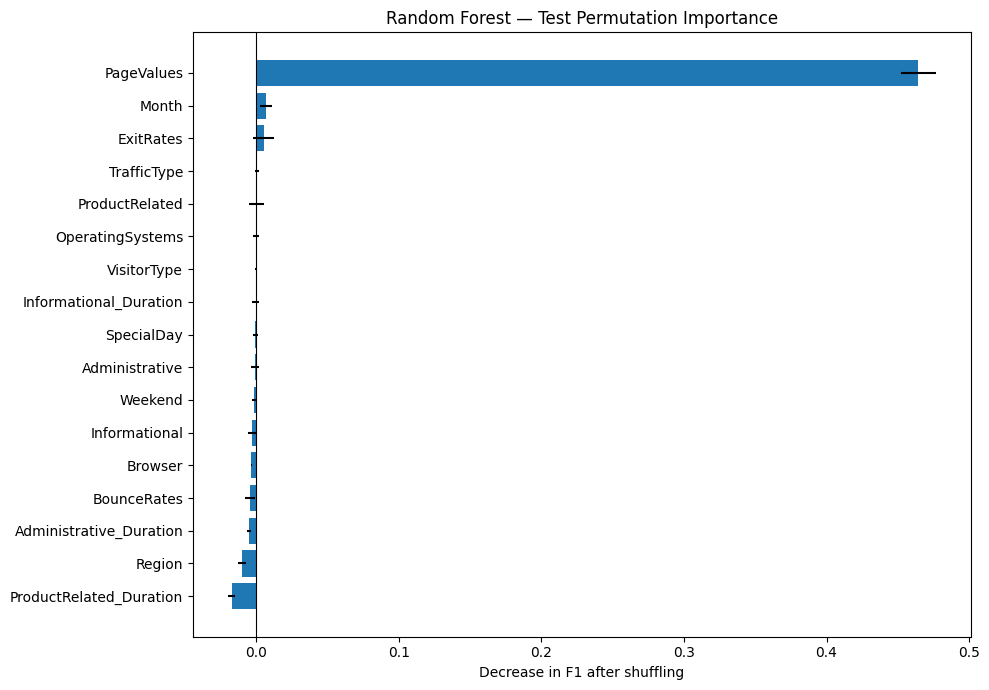

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [10]:
from sklearn.inspection import permutation_importance

# Impurity importance for encoded features.
feature_names = (
    final_model.named_steps["preprocessing"].get_feature_names_out()
)

impurity_table = pd.DataFrame({
    "Feature": feature_names,
    "Importance": final_model.named_steps["model"].feature_importances_
}).sort_values("Importance", ascending=False)

impurity_table.to_csv(
    OUTPUT_DIR / "impurity_importance.csv", index=False
)

top_features = impurity_table.head(15).sort_values("Importance")
plt.figure(figsize=(10, 7))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.xlabel("Impurity importance")
plt.title("Random Forest — Top 15 Encoded Features")
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "impurity_importance.png",
    dpi=200, bbox_inches="tight"
)
plt.show()
plt.close()

# Permutation importance for original input features.
# Interpretation only: final settings remain fixed.
print("Calculating permutation importance...", flush=True)

permutation_result = permutation_importance(
    final_model,
    X_test,
    y_test,
    scoring="f1",
    n_repeats=5,
    random_state=SEED,
    n_jobs=1
)

permutation_table = pd.DataFrame({
    "Feature": X_test.columns,
    "Mean F1 decrease": permutation_result.importances_mean,
    "Std": permutation_result.importances_std
}).sort_values("Mean F1 decrease", ascending=False)

permutation_table.to_csv(
    OUTPUT_DIR / "permutation_importance.csv", index=False
)

print(permutation_table.round(4).to_string(index=False))

plot_data = permutation_table.sort_values("Mean F1 decrease")
plt.figure(figsize=(10, 7))
plt.barh(
    plot_data["Feature"],
    plot_data["Mean F1 decrease"],
    xerr=plot_data["Std"]
)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Decrease in F1 after shuffling")
plt.title("Random Forest — Test Permutation Importance")
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "permutation_importance.png",
    dpi=200, bbox_inches="tight"
)
plt.show()
plt.close()

archive = shutil.make_archive(
    "/content/random_forest_results",
    "zip",
    root_dir=str(OUTPUT_DIR)
)
files.download(archive)

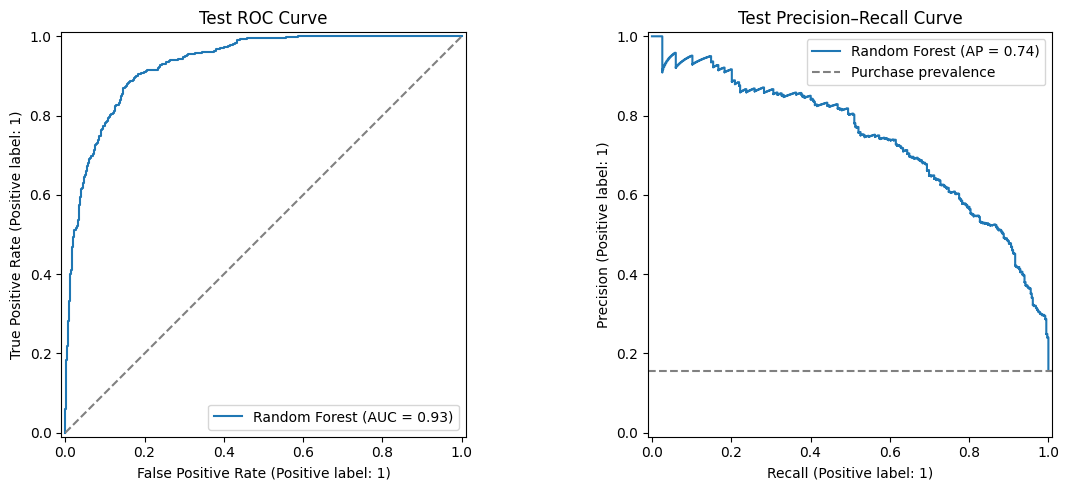

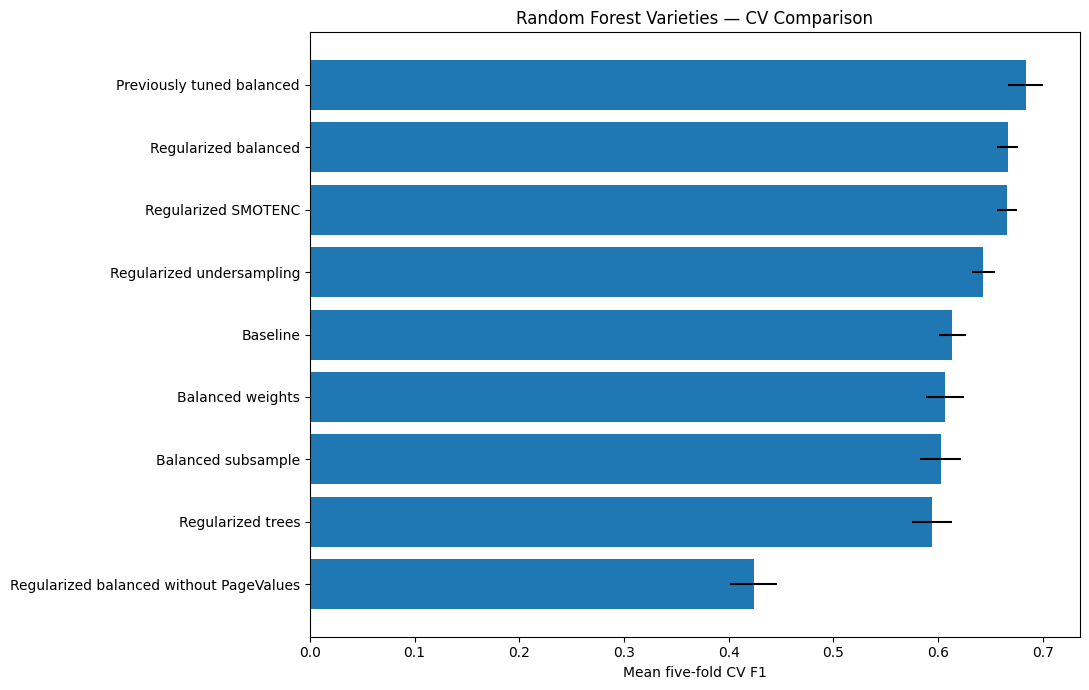

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Plots saved and updated ZIP download requested.


In [11]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

RocCurveDisplay.from_predictions(
    y_test, y_probability, ax=axes[0], name="Random Forest"
)
axes[0].plot([0, 1], [0, 1], "--", color="grey")
axes[0].set_title("Test ROC Curve")

PrecisionRecallDisplay.from_predictions(
    y_test, y_probability, ax=axes[1], name="Random Forest"
)
axes[1].axhline(
    y_test.mean(),
    linestyle="--",
    color="grey",
    label="Purchase prevalence"
)
axes[1].set_title("Test Precision–Recall Curve")
axes[1].legend()

plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "roc_pr_curves.png",
    dpi=200, bbox_inches="tight"
)
plt.show()
plt.close()

comparison = pd.DataFrame(cv_results.values()).sort_values("CV f1")

plt.figure(figsize=(11, 7))
plt.barh(
    comparison["Variety"],
    comparison["CV f1"],
    xerr=comparison["CV F1 std"]
)
plt.xlabel("Mean five-fold CV F1")
plt.title("Random Forest Varieties — CV Comparison")
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "cv_comparison.png",
    dpi=200, bbox_inches="tight"
)
plt.show()
plt.close()

archive = shutil.make_archive(
    "/content/random_forest_results",
    "zip",
    root_dir=str(OUTPUT_DIR)
)
files.download(archive)

print("Plots saved and updated ZIP download requested.")

In [12]:
# Pick five fixed test sessions for the demonstration.
sample = X_test.sample(n=5, random_state=SEED)

predictions = final_model.predict(sample)

positive_index = list(
    final_model.named_steps["model"].classes_
).index(1)

probabilities = final_model.predict_proba(sample)[:, positive_index]

demo = sample.copy()
demo["Actual purchase"] = y_test.loc[sample.index].map({
    0: "No", 1: "Yes"
})
demo["Predicted purchase"] = [
    "Yes" if prediction == 1 else "No"
    for prediction in predictions
]
demo["Purchase probability"] = probabilities.round(4)

display(demo)

demo.to_csv(OUTPUT_DIR / "prediction_samples.csv", index=False)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Actual purchase,Predicted purchase,Purchase probability
9320,0,0.0,0,0.0,5,256.500000,0.000000,0.040000,0.00000,0.0,Dec,2,2,3,3,Returning_Visitor,False,No,No,0.0059
373,4,61.0,0,0.0,14,175.666667,0.000000,0.010588,0.00000,0.0,Mar,2,2,5,2,Returning_Visitor,False,No,No,0.0041
6020,5,153.0,0,0.0,25,1074.683333,0.012500,0.018750,19.23269,0.0,Nov,1,1,6,4,Returning_Visitor,False,No,Yes,0.7284
9336,0,0.0,0,0.0,12,155.000000,0.066667,0.091667,0.00000,0.0,Nov,4,2,1,1,Returning_Visitor,False,No,No,0.1091
2439,2,90.0,0,0.0,22,650.666667,0.026087,0.045217,0.00000,0.0,May,2,2,4,1,Returning_Visitor,False,No,No,0.0078


In [13]:
display(demo[[
    "PageValues",
    "ProductRelated",
    "Month",
    "Actual purchase",
    "Predicted purchase",
    "Purchase probability"
]])

,PageValues,ProductRelated,Month,Actual purchase,Predicted purchase,Purchase probability
9320,0.00000,5,Dec,No,No,0.0059
373,0.00000,14,Mar,No,No,0.0041
6020,19.23269,25,Nov,No,Yes,0.7284
9336,0.00000,12,Nov,No,No,0.1091
2439,0.00000,22,May,No,No,0.0078
